In [2]:

import torch, torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
import time
import os
import cv2
from preparationDataset import PreparationDataset
from imutils import paths
from sklearn.model_selection import train_test_split
from torch.nn import Module

In [29]:

dataset_path = "/Users/beyzaecemerce/Desktop/GitHub/thesis/drone"
image_path=dataset_path+'/dataset/semantic_drone_dataset/original_images'
masked_path = dataset_path+ '/RGB_color_image_masks/RGB_color_image_masks'
TEST_SPLIT = 0.10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PIN_MEMORY = True if DEVICE == "cuda" else False

In [30]:
masked_path

'/Users/beyzaecemerce/Desktop/GitHub/thesis/drone/RGB_color_image_masks/RGB_color_image_masks'

In [26]:
masked_path+"/000.png"


'/RGB_color_image_masks/RGB_color_image_masks/000.png'

(4000, 6000, 3)
(4000, 6000, 3)


/var/folders/xy/y85s_w552q1_8cd2gzzrqfmc0000gn/T/ipykernel_93266/754042599.py:13: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  figure.show()


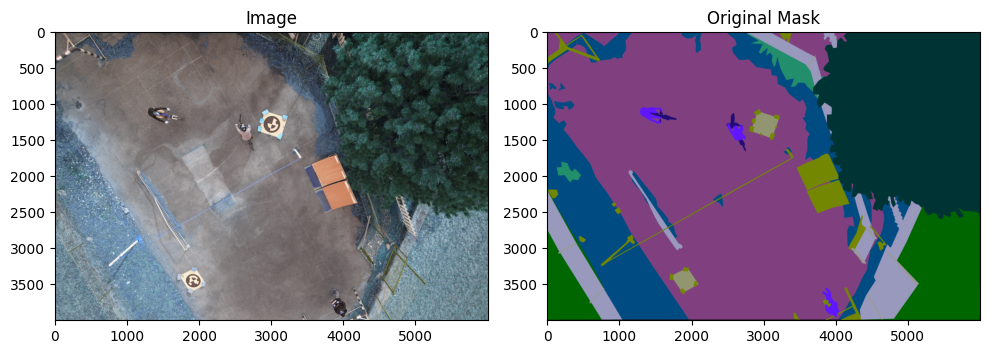

In [34]:
image = cv2.imread(image_path+"/100.jpg")
mask=cv2.imread(masked_path+"/100.png")
print(image.shape)
print(mask.shape)
figure, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 10))
ax[0].grid(False)
ax[1].grid(False)
ax[0].imshow(image)
ax[1].imshow(mask)
ax[0].set_title("Image")
ax[1].set_title("Original Mask")
figure.tight_layout()
figure.show()

In [ ]:
transforms = transforms.Compose([transforms.ToPILImage(),transforms.Resize((704,1056), interpolation=cv2.INTER_NEAREST),transforms.ToTensor()])


In [ ]:
INIT_LR = 2e-4
NUM_EPOCHS = 300
BATCH_SIZE = 8

INPUT_IMAGE_WIDTH = 6000
INPUT_IMAGE_HEIGHT = 4000

BASE_OUTPUT = dataset_path+"output"

MODEL_PATH = os.path.join(BASE_OUTPUT, "MODEL.pth")
PLOT_PATH = os.path.sep.join([BASE_OUTPUT, "Train_Test_Plot.png"])
TEST_PATHS = os.path.sep.join([BASE_OUTPUT, "test_path.txt"])